# 🎉 Análise de dados do Carnaval do Rio de Janeiro entre 1996-2026

## 📚 Introdução

A ideia de analisar os resultados do carnaval surgiu de uma paixão pessoal pela festa, pela cultura dos desfiles e das tradições das escolas de samba. A disputa do carnaval da Sapucaí é envolvida por uma mística popular de emoção e torcida, e por um conjunto de critérios, muitas vezes de natureza subjetiva, que impõe a qualquer análise as mesmas dificuldades: para além do amor à sua própria escola, quando a análise vem de dentro desse contexto (meu caso), se põe no caminho também a complexidade de estabelecer relações de causa e efeito, ou de hierarquia estética, ou de qualquer natureza, que explique os resultados e os desempenhos das agremiações na avenida. Por isso, essa análise entende que não há como responder perguntas como "qual escola foi a melhor/pior em tal ano?", ou "qual escola é melhor/pior em tal quesito?", ou ainda "por que uma escola tirou nota X e não Y em um determinado ano?". Essas são perguntas que, inevitavelmente, esbarram em decisões subjetivas dos diversos indivíduos que já ocuparam as cabines de jurados da Sapucaí e seria impossível explicá-las uma por uma. O que podemos tentar fazer, por outro lado, é entender padrões nessas decisões, analisando-as ao longo de um extenso período histórico para explicar, por exemplo, quais são as forças estruturais de cada escola, ou entender a evolução de cada escola em cada critério ao longo desse período. Essas sim, são informações que podemos vislumbrar a partir de dados objetivos.


## 🔬 Metodologia e opções conceituais

O carnaval do Rio, desde meados dos anos 80, é disputado segundo regras institucionalizadas por uma organização autônoma, a Liga Independente das Escolas de Samba. Portanto, quando dizemos que determinada escola ganhou nota X no quesito bateria, isso quer dizer que sua bateria foi analisada por um jurado, que lhe atribuiu uma nota de acordo com critérios dessa competição específica, estabelecida por essa organização específica. Essa nota, então, é capaz de capturar não só a adequação desse elemento da escola a essas normas, mas também a percepção daquele jurado específico a respeito desse elemento e segundo essas normas. Isso, por sua vez, significa que podemos de certa forma mensurar um comportamento médio dos jurados ao longo do tempo. Há, por fim, uma última opção a ser justificada: a restrição ao Grupo Especial. O carnaval do Rio de Janeiro é disputado em grupos hierarquicamente organizados, mais ou menos análogo ao Campeonato Brasileiro de Futebol: o Grupo Especial é a primeira divisão, composto por 12 escolas em cada ano, a Série Ouro é a segunda, composta por 15 escolas, a Série Prata é a terceira, com 29 escolas, seguida da Série Bronze, com 20. Além disso, há o Grupo de Avaliação, com 15 escolas. As regras em cada divisão divergem no mesmo ano, dificultando a comparação, e além disso a enorme quantidade de escolas diluiria exageradamente quaisquer conclusões. Opta-se, portanto, por analisar apenas os carnavais disputados no Grupo Especial e, na maioria das vezes, um conjunto recortado das escolas.

### O problema da variação de regras

A escolha pela análise de todas as notas, inclusive as eventualmente descartadas, em todos os quesitos de cada competição desde 1996, segue essa linha de raciocínio: o jurado que atribui uma nota não sabe se sua nota será aproveitada ou descartada no momento da atribuição, porque não tem como compará-la com as outras (e, se tivesse, certamente tentaria adequá-la para garantir que seja levada em conta na contagem). Não há, portanto, motivo para que seja descartada se nosso objetivo for justamente identificar um comportamento médio dos jurados ao longo dos anos para entender como as agremiações se relacionam com ele. Isso também é capaz de nivelar as muitas mudanças nas regras que a LIESA implementou ao longo dos anos, a fim de aperfeiçoar e tornar mais justa a competição. Por exemplo, o descarte, que hoje desde 2010 é necessariamente da nota mais baixa em cada quesito entre quatro notas, já foi da mais alta e da mais baixa entre cinco no passado, ou sorteado; em alguns anos, não houve descarte. A variação na quantidade de jurados, de três a cinco dependendo do ano, também é notória, para não falar de casos específicos como os do jurado do quesito Conjunto, Adilson Gomes de Oliveira, em 2004, e a anulação das notas de um dos jurados de bateria nesse mesmo ano por decisão da LIESA após confirmação de quebra de sigilo. Nem mesmo os quesitos foram os mesmos em todos os anos: Conjunto, por exemplo, deixou de existir por votação interna em 2014. Essa análise pretende, por outro lado, captar o que persiste e evolui *apesar* dessas mudanças: a percepção dos jurados. Essa é a dimensão granular dos dados analisados, que permite adicionar complexidade para além dos cálculos finais em cada ano.


### Estrutura dos dados

Todos os dados analisados foram coletados e tratados por um pipeline ETL desenvolvido em Python para esse projeto, [disponível em código aberto no GitHub](https://github.com/flipvieira/rescar_public), e carregados em um banco de dados SQL cuja estrutura também está disponível no mesmo repositório. A tabela principal, de resultados, tem cinco colunas: "escola, ano, quesito, jurado, nota". Cada linha, por tanto, segue esse formato: Beija-Flor, 1996, Bateria, J1, 10. Há mais duas tabelas por motivos de organização: uma para registrar as escolas que já passaram pelo grupo especial nesses últimos 30 anos, outra para registrar os quesitos.


### *Extract, transform e load*

O site da LIESA seria uma fonte primária por excelência. Entretanto, disponibiliza apenas os dados dos últimos 20 carnavais e, mesmo assim, a maioria em formato PDF, boa parte como imagem, o que dificultaria a extração direta sem uma enorme quantidade de recursos e a eficiência no acesso a esses dados em uma pequena quantidade de tempo disponível. Isso explica a opção pelas páginas da Wikipedia dedicadas à exposição dos resultados ao longo dos anos, que além de hospedar resultados até bem anteriores ao marco temporal recortado aqui, também padronizou as tabelas de forma que a automatização da extração por scripts de um enorme volume de dados seja possível, em poucos segundos. A transformação, a limpeza e outros processos de tratamento dos dados também é feita com scripts escritos para o formato específico de dados tratados, e o *load* é realizado em um banco de dados SQL (PostgreSQL) hospedado no Supabase. Esse formato de pipeline foi pensado tendo em vista a eficiência na fluição dos dados de uma ponta a outra, mas também a possibilidade de reprodução por qualquer pessoa com acesso ao código-fonte.


## 🎯 Objetivos da análise

Os principais objetivos dessa análise, destrinchados entre os pequenos *insights* que serão apresentados através de observações e gráficos, são:
- capturar o comportamento médio dos jurados em cada quesito ao longo dos anos;
- mostrar a evolução das escolas em cada quesito ao longo dos anos;
- entender as forças estruturais de cada escola e como essa força evolui ao longo dos anos.


## 🛠️ Ferramentas

- Python 🐍 (no ETL e na visualização com Pandas, Seaborn e Matplotlib)
- SQL 🗄️ (organização e queries específicas para o projeto)
- JupyterLab 📔 (exposição explicada das análises)

## Código: importações, configurações, etc.

In [2]:
# Importação de bibliotecas

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

In [3]:
# Importação do arquivo .csv contendo os dados da tabela 'resultados' extraídos do banco SQL

res = pd.read_csv('rescar_1996-2026.csv')

print(res.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15441 entries, 0 to 15440
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   sigla    15441 non-null  object 
 1   ano      15441 non-null  int64  
 2   quesito  15441 non-null  object 
 3   jurado   15441 non-null  object 
 4   nota     15422 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 603.3+ KB
None


In [4]:
# Estabelecendo as médias por quesito e filtrando escolas


# Quesitos

res_bat = res[res['quesito'] == 'Bateria']
res_enr = res[res['quesito'] == 'Enredo']
res_evo = res[res['quesito'] == 'Evolução']
res_msp = res[res['quesito'] == 'Mestre-Sala e Porta-Bandeira']
res_cmf = res[res['quesito'] == 'Comissão de Frente']
res_alg = res[res['quesito'] == 'Alegorias e Adereços']
res_har = res[res['quesito'] == 'Harmonia']
res_fan = res[res['quesito'] == 'Fantasia']
res_sbe = res[res['quesito'] == 'Samba-Enredo']


# Médias agrupadas por escola e ano

res_bat_grouped = (res_bat.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_enr_grouped = (res_enr.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_evo_grouped = (res_evo.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_msp_grouped = (res_msp.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_cmf_grouped = (res_cmf.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_alg_grouped = (res_alg.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_har_grouped = (res_har.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_fan_grouped = (res_fan.groupby(["sigla", "ano"])["nota"].mean().reset_index())
res_sbe_grouped = (res_sbe.groupby(["sigla", "ano"])["nota"].mean().reset_index())


# Filtro de escolas

esc = ['POR', 'MOC', 'MAN', 'BJF', 'SAL', 'VIS']


# Quesitos filtrados por escola

res_filter_bat = res_bat_grouped[res_bat_grouped["sigla"].isin(esc)]
res_filter_enr = res_enr_grouped[res_enr_grouped["sigla"].isin(esc)]
res_filter_evo = res_evo_grouped[res_evo_grouped["sigla"].isin(esc)]
res_filter_msp = res_msp_grouped[res_msp_grouped["sigla"].isin(esc)]
res_filter_cmf = res_cmf_grouped[res_cmf_grouped["sigla"].isin(esc)]
res_filter_alg = res_alg_grouped[res_alg_grouped["sigla"].isin(esc)]
res_filter_har = res_har_grouped[res_har_grouped["sigla"].isin(esc)]
res_filter_fan = res_fan_grouped[res_fan_grouped["sigla"].isin(esc)]
res_filter_sbe = res_sbe_grouped[res_sbe_grouped["sigla"].isin(esc)]

In [5]:
# Configurações gerais de visualização

sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))

cores_esc = {
    'POR': '#2596be',
    'MOC': '#2bcf83',
    'MAN': '#f962ff',
    'BJF': '#62fbff',
    'SAL': '#ff6262',
    'VIS': '#90d9f1'
}

<Figure size 1000x600 with 0 Axes>

## Visualização

### Evolução e tendências por quesito entre 1996 e 2026

A seção presente tem como objetivo visualizar a evolução do comportamento dos jurados em relação aos quesitos e às escolas nos 30 últimos carnavais.

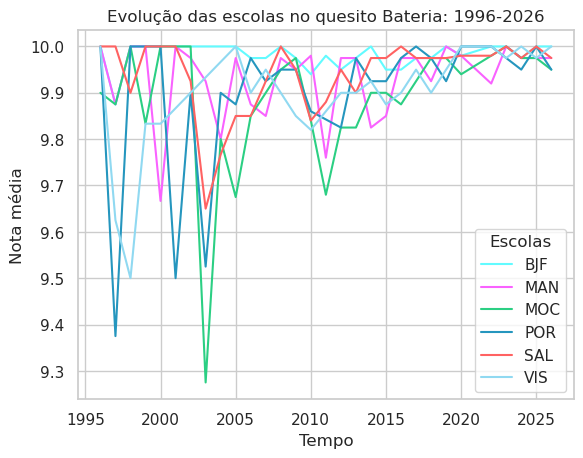

In [6]:
# Gráfico 1: Evolução das escolas no quesito Bateria: 1996-2026

sns.lineplot(
    data=res_filter_bat,
    x='ano',
    y='nota',
    hue='sigla',
    palette=cores_esc)

plt.title('Evolução das escolas no quesito Bateria: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Escolas')
plt.show()

O gráfico acima mostra a evolução das notas de cada escola no quesito Bateria nos últimos 30 anos, levando em consideração apenas um recorte de 6 escolas populares. A primeira observação que podemos fazer é a de que **entre 1996 e 2026 o comportamento dos jurados mudou muito**: se antes eram mais comuns grandes variações de nota, refletidas na média, como a da Mocidade Independente de Padre Miguel, que foi de 10 a 9.2 (quase 1 ponto de variação) em um intervalo insignificante de tempo, percebe-se uma tendência generalizada de diminuição dessa variação a partir do início da década de 2010. Isso se deve, provavelmente, a mais de um fator. Começando pela mudança da regra que estabelece uma nota mínima: antes de 2010, a nota por jurado podia variar entre 7 e 10, e depois, em 2011, entre 8 e 10; por fim, em 2012 a variação foi fixada entre 9 e 10 com retirada de décimos, modelo vigente até hoje. O que mais chama a atenção é perceber que as regras influenciam não apenas quantitativa, mas também qualitativamente a percepção dos jurados: a possibilidade de variar entre 7 e 10 legitima notas mais baixas mesmo entre frações decimais de 9 a 10, enquanto a diminuição do campo de flutuação para valores entre 9 e 10 forçou uma estabilidade nas variações de média que, se não fogem muito do padrão, não saem das cercanias dos 3 décimos. Abaixo, veremos se essa tendência se repete em outros quesitos

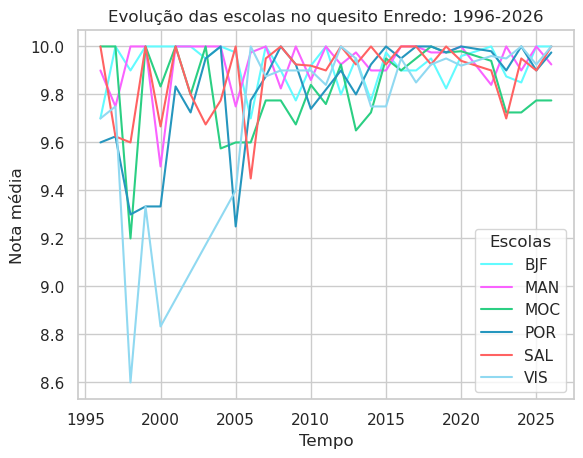

In [7]:
# Gráfico 2: Evolução das escolas no quesito Enredo: 1996-2026

sns.lineplot(
    data=res_filter_enr,
    x='ano',
    y='nota',
    hue='sigla',
    palette=cores_esc)

plt.title('Evolução das escolas no quesito Enredo: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Escolas')
plt.show()

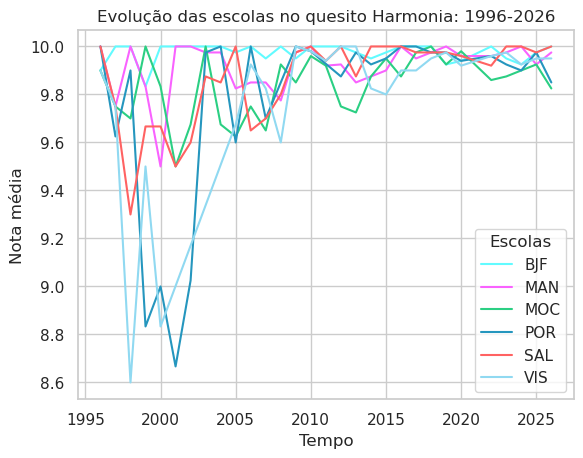

In [8]:
# Gráfico 3: Evolução das escolas no quesito Harmonia: 1996-2026

sns.lineplot(
    data=res_filter_har,
    x='ano',
    y='nota',
    hue='sigla',
    palette=cores_esc)

plt.title('Evolução das escolas no quesito Harmonia: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Escolas')
plt.show()

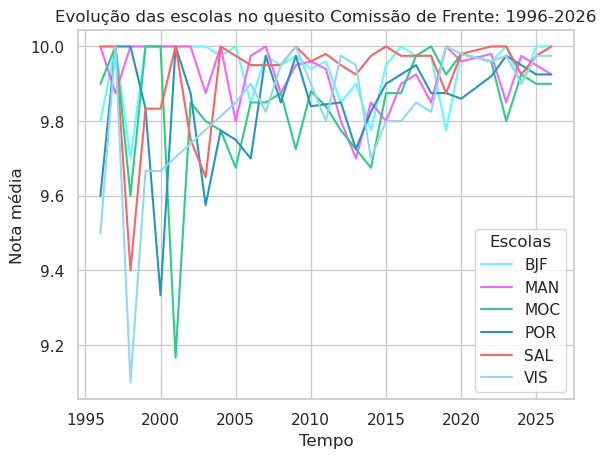

In [9]:
# Gráfico 4: Evolução das escolas no quesito Comissão de Frente: 1996-2026

sns.lineplot(
    data=res_filter_cmf,
    x='ano',
    y='nota',
    hue='sigla',
    palette=cores_esc)

plt.title('Evolução das escolas no quesito Comissão de Frente: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Escolas')
plt.show()

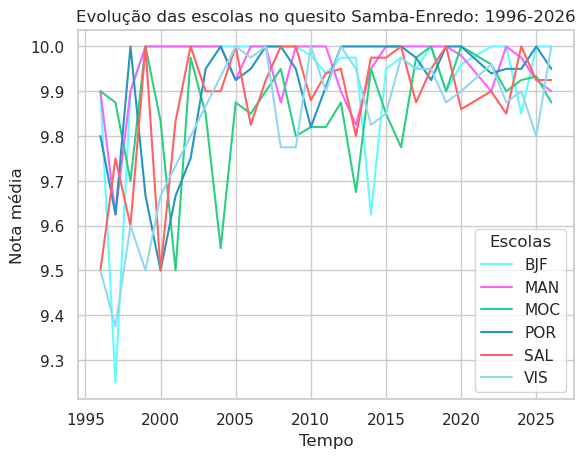

In [10]:
# Gráfico 5: Evolução das escolas no quesito Samba-Enredo: 1996-2026

sns.lineplot(
    data=res_filter_sbe,
    x='ano',
    y='nota',
    hue='sigla',
    palette=cores_esc)

plt.title('Evolução das escolas no quesito Samba-Enredo: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Escolas')
plt.show()

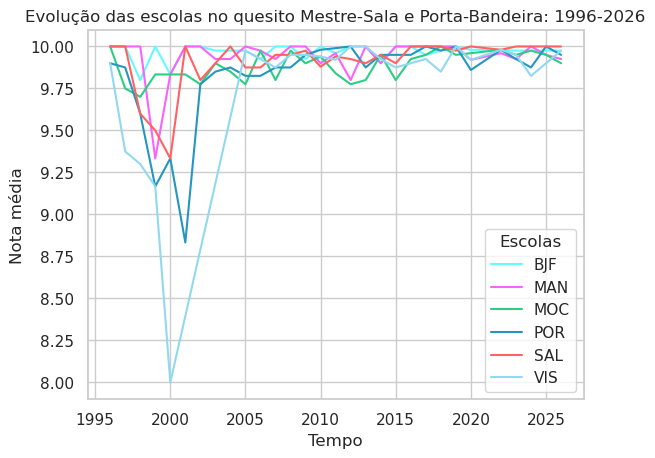

In [11]:
# Gráfico 6: Evolução das escolas no quesito Mestre-Sala e Porta-Bandeira: 1996-2026

sns.lineplot(
    data=res_filter_msp,
    x='ano',
    y='nota',
    hue='sigla',
    palette=cores_esc,
)

plt.title('Evolução das escolas no quesito Mestre-Sala e Porta-Bandeira: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Escolas')
plt.show()

Embora alguns quesitos, como Samba-Enredo e Comissão de Frente, continuem variando bastante, acompanham a tendência de estabilização sugerida pela primeira figura. O gráfico a seguir engloba todos os quesitos e distribui a média de nota em cada um por ano, a fim de facilitar a visualização dessa tendência geral:

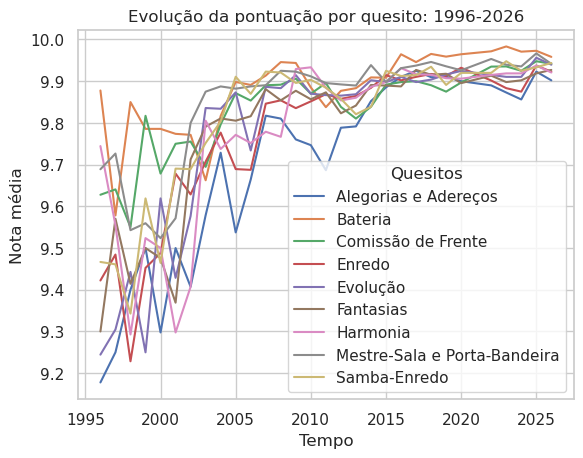

In [12]:
# Gráfico 7: Evolução da pontuação por quesito: 1996-2026

res_ques = ['Alegorias e Adereços', 'Bateria', 'Comissão de Frente', 'Enredo', 'Evolução', 'Fantasias', 'Harmonia', 'Mestre-Sala e Porta-Bandeira', 'Samba-Enredo']
res_filter = res[res['quesito'].isin(res_ques)]

res_ques_grouped = (res_filter.groupby(['ano', 'quesito'])['nota'].mean().reset_index())

sns.lineplot(
    data=res_ques_grouped,
    x='ano',
    y='nota',
    hue='quesito')

plt.title('Evolução da pontuação por quesito: 1996-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Quesitos')
plt.show()

A tendência de estabilização a partir de 2010 é generalizada, em menor ou menor grau; **o destaque é para o quesito Bateria, que a partir do início da segunda metade da década é o mais estável**. A que isso se deve exatamente é difícil afirmar com certeza dentre as múltiplas razões, mas a comunicação orgânica entre as baterias das escolas de samba sempre ocorre, e não é incomum a circulação de ritmistas e mestres entre elas. De qualquer forma, deve haver um motivo pelo qual esse quesito se tornou o mais estável *na percepção dos jurados*, e a objetividade disso culmina nas novas regras de julgamento da bateria que a LIESA apresentou em 2026: o quesito agora é dividido em subquesitos técnicos, como "manutenção da cadência", "conjugação dos instrumentos" e "criatividade e versatilidade". Em uma instância mais profunda, parece que as baterias das escolas, salvas as identidades de cada uma, tendem a se comportar de forma convergente pelo menos na percepção dos jurados. Em relação ao comportamento dos jurados, a tendência à estabilidade pode mostrar também uma evolução do rigor na aplicação de notas.

### Forças estruturais

Impressões estruturais de cada escola por quesito entre 1996 e 2026.

In [13]:
# Filtro de escolas e período

res_BJF = res[(res['sigla'] == 'BJF') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 1996) & (res['ano'] <= 2026)]
res_MAN = res[(res['sigla'] == 'MAN') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 1996) & (res['ano'] <= 2026)]
res_MOC = res[(res['sigla'] == 'MOC') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 1996) & (res['ano'] <= 2026)]
res_POR = res[(res['sigla'] == 'POR') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 1996) & (res['ano'] <= 2026)]
res_SAL = res[(res['sigla'] == 'SAL') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 1996) & (res['ano'] <= 2026)]
res_VIS = res[(res['sigla'] == 'VIS') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 1996) & (res['ano'] <= 2026)]

Os gráficos abaixo ressaltam a força histórica de cada escola nos diferentes quesitos ou, posto de outra forma, entre as notas médias que essas escolas receberam dos jurados no período 1996-2026, quais foram as maiores no geral.

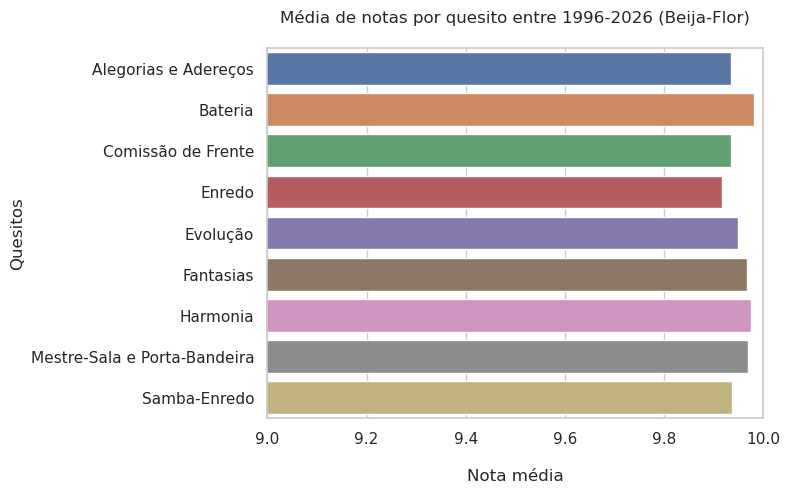

In [14]:
# Gráfico 8: Média de notas por quesito entre 1996-2026 (Beija-Flor)

media_quesito = (
    res_BJF
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 1996-2026 (Beija-Flor)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

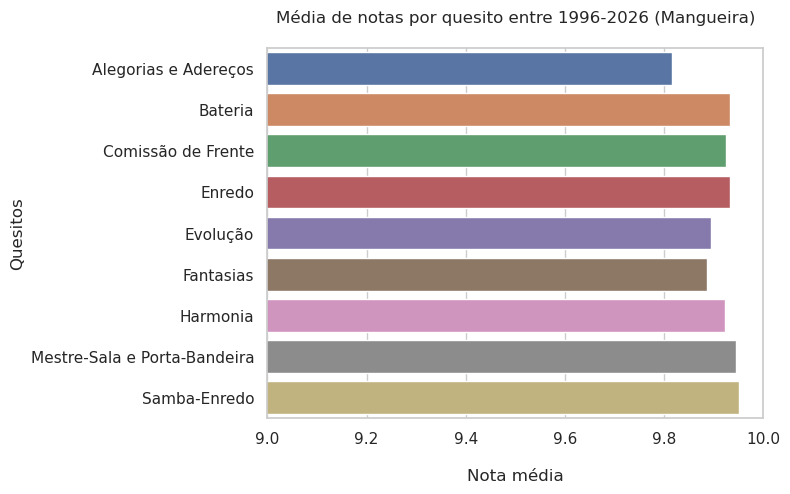

In [15]:
# Gráfico 9: Média de notas por quesito entre 1996-2026 (Mangueira)

media_quesito = (
    res_MAN
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 1996-2026 (Mangueira)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

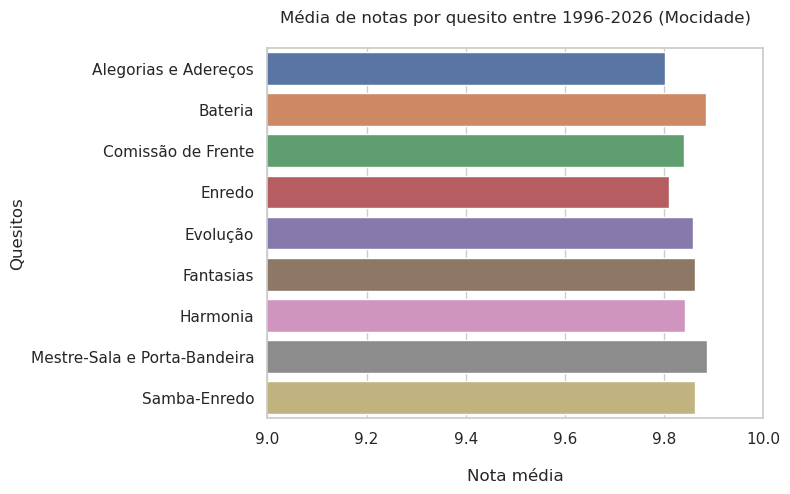

In [16]:
# Gráfico 10: Média de notas por quesito entre 1996-2026 (Mocidade)

media_quesito = (
    res_MOC
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 1996-2026 (Mocidade)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

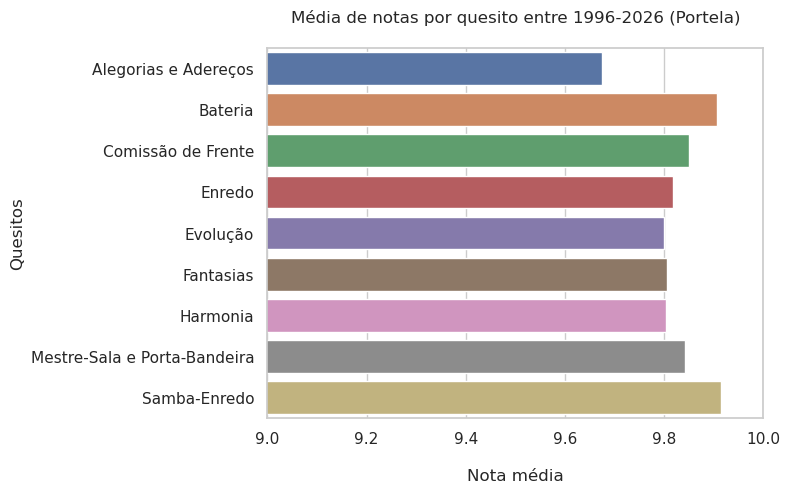

In [17]:
# Gráfico 11: Média de notas por quesito entre 1996-2026 (Portela)

media_quesito = (
    res_POR
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 1996-2026 (Portela)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

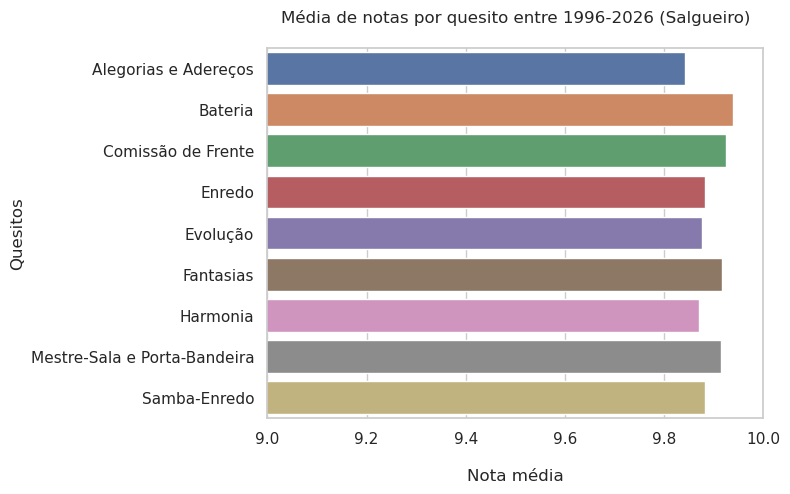

In [18]:
# Gráfico 12: Média de notas por quesito entre 1996-2026 (Salgueiro)

media_quesito = (
    res_SAL
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 1996-2026 (Salgueiro)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

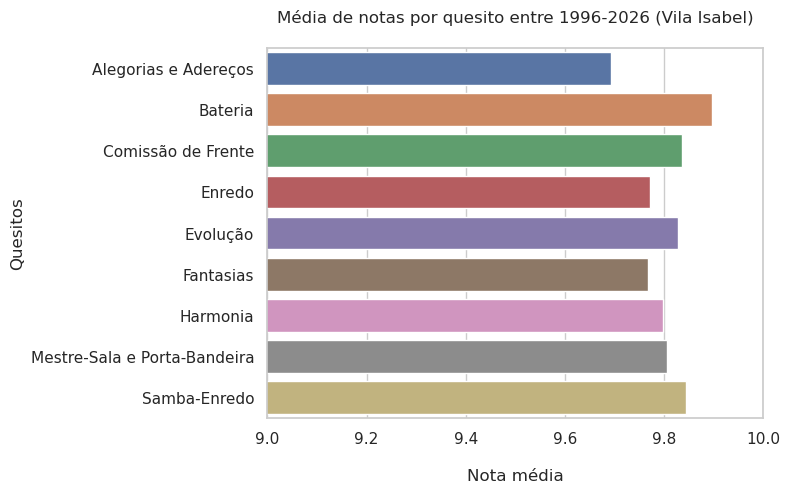

In [19]:
# Gráfico 13: Média de notas por quesito entre 1996-2026 (Vila Isabel)

media_quesito = (
    res_VIS
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 1996-2026 (Vila Isabel)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

Salta à vista a diferença entre a Beija-Flor de Nilópolis e as demais escolas analisadas, mostrando uma **distinção no comportamento dos jurados frente à agremiação nilopolitana** para além do seu bom desempenho histórico na bateria. Ademais, percebemos também que:
- a maior força estrutural da Mangueira é o samba-enredo seguido por mestre-sala e porta-bandeira;
- as da Mocidade são, praticamente empatadas, bateria e mestre-sala e porta-bandeira;
- a Portela tem melhor desempenho médio em bateria e samba-enredo;
- o Salgueiro tem certo equilíbrio entre bateria, fantasias e mestre-sala e porta-bandeira;
- o desempenho médio da Vila Isabel no quesito bateria é superior a todos os outros, seguido do samba-enredo.

### *Ranking* justo das escolas: um *top* 3 em cada quesito

In [20]:
# Definição de médias e filtros de escola e quesito

medias = res.groupby(['quesito', 'sigla'])['nota'].mean().reset_index()

ques_filter = ['Alegorias e Adereços', 'Bateria', 'Comissão de Frente', 'Enredo', 'Evolução', 'Fantasias', 'Harmonia', 'Mestre-Sala e Porta-Bandeira', 'Samba-Enredo']
esc_filter = ['BJF', 'MAN', 'MOC', 'POR', 'SAL', 'VIS']

In [21]:
# Função que rankeia as 3 escolas com maior média em cada quesito

def rank5(ques):
    return medias[(medias['quesito'] == ques) & (medias['sigla'].isin(esc_filter))].sort_values('nota', ascending=False).head(3)

In [22]:
# Itera por quesito aplicando a função

for quesito in ques_filter:
    display(Markdown(f"**{quesito}**"))
    display(rank5(quesito)[['sigla', 'nota']].reset_index(drop=True).style.format({'nota': '{:.3f}'}).hide(axis='index'))

**Alegorias e Adereços**

sigla,nota
BJF,9.935
SAL,9.841
MAN,9.816


**Bateria**

sigla,nota
BJF,9.981
SAL,9.939
MAN,9.934


**Comissão de Frente**

...

sigla,nota
BJF,9.975
MAN,9.923
SAL,9.870


**Mestre-Sala e Porta-Bandeira**

sigla,nota
BJF,9.968
MAN,9.945
SAL,9.914


**Samba-Enredo**

sigla,nota
MAN,9.951
BJF,9.937
POR,9.914


A saída dos blocos de código acima apresentam um *insight* interessante: entre as escolas analisadas até agora, a Beija-Flor é a primeira colocada no *top* 3 de todos os quesitos com exceção de enredo e samba-enredo, onde a Mangueira se sobressai. O Salgueiro fica em segundo em 3 quesitos: alegorias e adereços, bateria e fantasias. A Portela só aparece em samba-enredo, na terceira colocação. O que ocorreria se o filtro de escolas fosse removido e todas as escolas que já passaram pelo Grupo Especial nesses últimos 30 anos fossem adicionadas à equação? Os blocos abaixo dão conta disso:

In [23]:
# Itera por quesito, sem filtro, aplicando a função

def rank5_filterless(ques):
    return medias[medias['quesito'] == ques].sort_values('nota', ascending=False).head(3)

for quesito in ques_filter:
    display(Markdown(f"**{quesito}**"))
    display(rank5_filterless(quesito)[['sigla', 'nota']].reset_index(drop=True).style.format({'nota': '{:.3f}'}).hide(axis='index'))

**Alegorias e Adereços**

sigla,nota
BJF,9.935
IMP,9.878
GRA,9.847


**Bateria**

sigla,nota
BJF,9.981
SAL,9.939
IMP,9.934


**Comissão de Frente**

...

sigla,nota
BJF,9.975
MAN,9.923
IMP,9.894


**Mestre-Sala e Porta-Bandeira**

sigla,nota
BJF,9.968
MAN,9.945
IMP,9.930


**Samba-Enredo**

sigla,nota
MAN,9.951
NIT,9.950
BJF,9.937


De todas as escolas que já passaram pelo Grupo Especial entre 1996 e 2026, **a Beija-Flor ainda lidera a maioria dos rankings**, mas agora com algumas surpresas: a maior média em nota no quesito enredo é da Unidos de Padre Miguel, que só esteve no Grupo Especial na competição de 2025 e foi rebaixada sob polêmicas envolvendo o enredo e o samba-enredo, com jurados alegando "excesso" de palavras em Iorubá. O Império Serrano, escola tradicional que permaneceu no Grupo Especial em 14 dos 30 anos analisados, se destaca com a terceira maior média nos quesitos bateria, harmonia e mestre-sala e porta-bandeira, e a segunda maior em alegorias e adereços, comissão de frente e fantasias.

### Um recorte menor: 2016-2026

A tendência de estabilização nas notas que se mostra a partir de 2010 sugere que talvez a breve análise de um período iniciado depois disso revele padrões diferentes. Como o marco temporal analisado como um todo são 30 anos, pareceu adequado o subrecorte de 10 anos, no último terço do marco completo, para tentar capturar uma diferença significativa de comportamento.

In [24]:
# Filtro de escolas e período (recente)

res_BJF_rec = res[(res['sigla'] == 'BJF') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 2016) & (res['ano'] <= 2026)]
res_MAN_rec = res[(res['sigla'] == 'MAN') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 2016) & (res['ano'] <= 2026)]
res_MOC_rec = res[(res['sigla'] == 'MOC') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 2016) & (res['ano'] <= 2026)]
res_POR_rec = res[(res['sigla'] == 'POR') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 2016) & (res['ano'] <= 2026)]
res_SAL_rec = res[(res['sigla'] == 'SAL') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 2016) & (res['ano'] <= 2026)]
res_VIS_rec = res[(res['sigla'] == 'VIS') & (res['quesito'] != 'Pen.') & (res['quesito'] != 'Conjunto') & (res['ano'] >= 2016) & (res['ano'] <= 2026)]

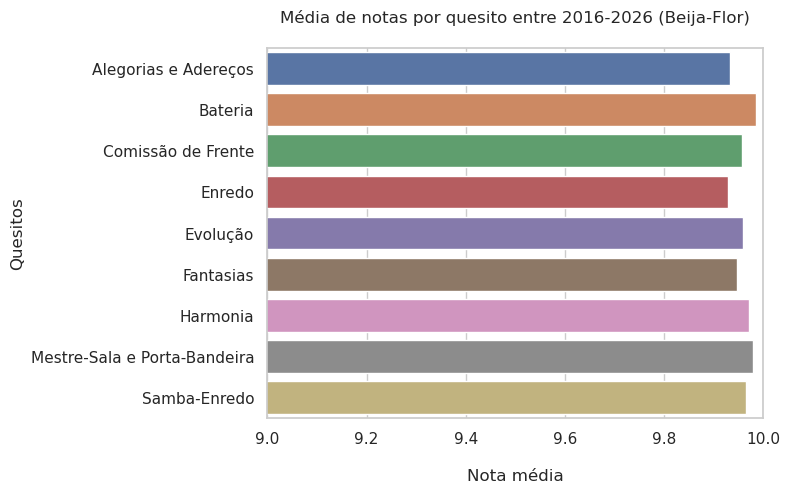

In [25]:
# Gráfico 14: Média de notas por quesito entre 2016-2026 (Beija-Flor)

media_quesito = (
    res_BJF_rec
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 2016-2026 (Beija-Flor)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

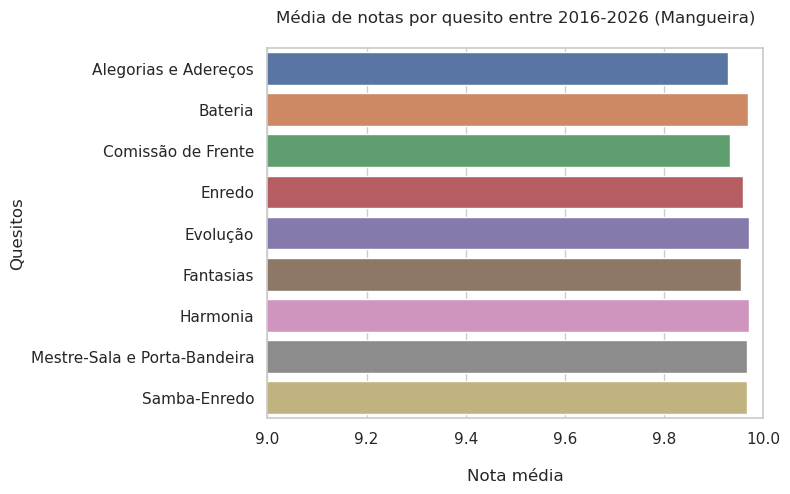

In [26]:
# Gráfico 15: Média de notas por quesito entre 2016-2026 (Mangueira)

media_quesito = (
    res_MAN_rec
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 2016-2026 (Mangueira)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

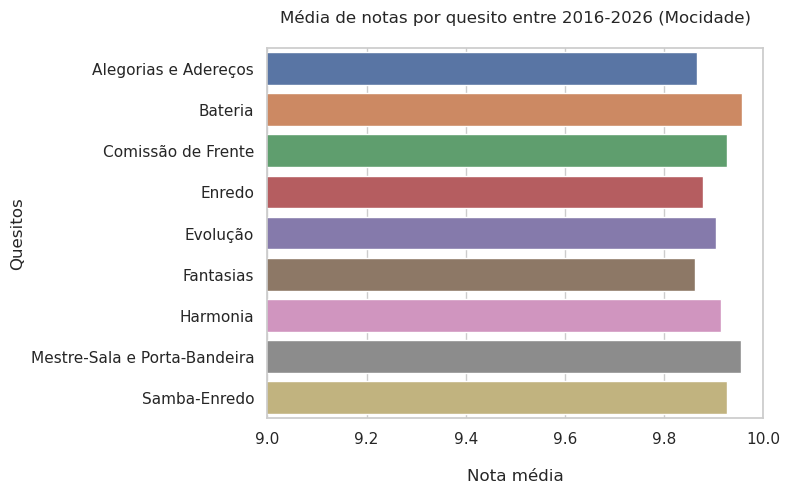

In [27]:
# Gráfico 16: Média de notas por quesito entre 2016-2026 (Mocidade)

media_quesito = (
    res_MOC_rec
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 2016-2026 (Mocidade)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

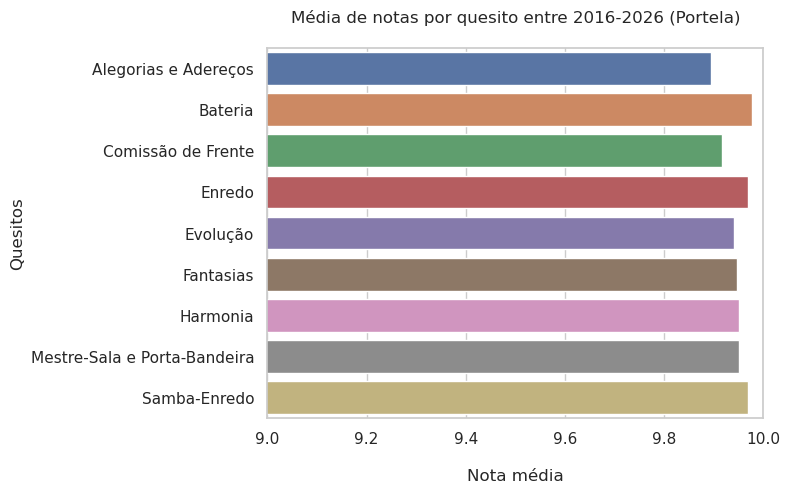

In [28]:
# Gráfico 14: Média de notas por quesito entre 2016-2026 (Portela)

media_quesito = (
    res_POR_rec
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 2016-2026 (Portela)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

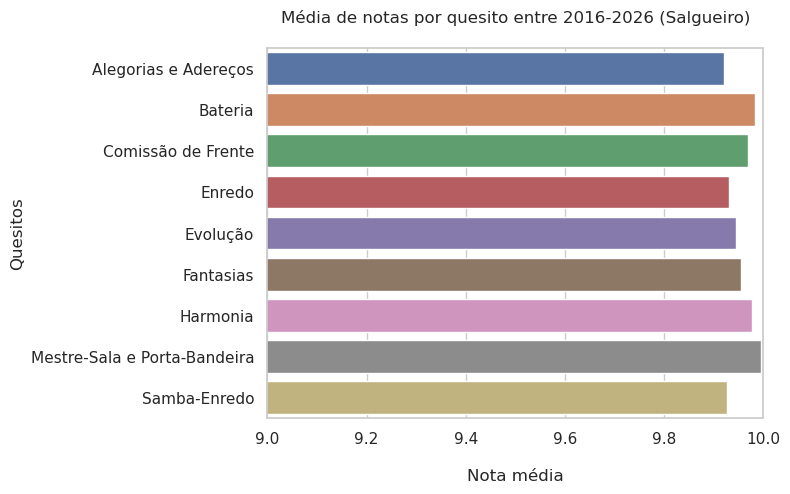

In [29]:
# Gráfico 14: Média de notas por quesito entre 2016-2026 (Salgueiro)

media_quesito = (
    res_SAL_rec
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 2016-2026 (Salgueiro)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

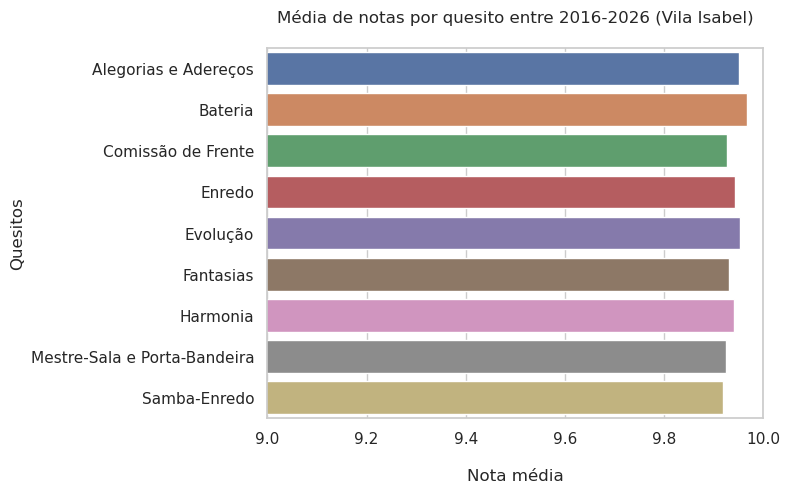

In [30]:
# Gráfico 14: Média de notas por quesito entre 2016-2026 (Vila-Isabel)

media_quesito = (
    res_VIS_rec
    .groupby('quesito')['nota']
    .mean()
    .reset_index()
)

sns.barplot(
    data=media_quesito,
    x='nota',
    y='quesito',
    hue='quesito'
)

plt.title('Média de notas por quesito entre 2016-2026 (Vila Isabel)\n')
plt.xlim(9, 10)
plt.ylabel('Quesitos')
plt.xlabel('\nNota média')
plt.show()

Tanto a distância entre uma escola e outra nas forças estruturais que representam para os jurados em cada quesito quanto a soberania indiscutível da Beija-Flor se achatam sutilmente neste período da última década, acompanhando a mudança de comportamento na aplicação de notas. Praticamente todas as escolas nesse recorte mais curto se destacam pela bateria, entre as notas médias que recebem por quesito, e com poucas exceções (como no caso das notas médias da Mocidade por quesito, ainda distantes umas das outras) diminuiu também a distância entre os quesitos de uma mesma escola. No gráfico abaixo, vemos a evolução das notas médias em todos os quesitos entre 2016 e 2026:

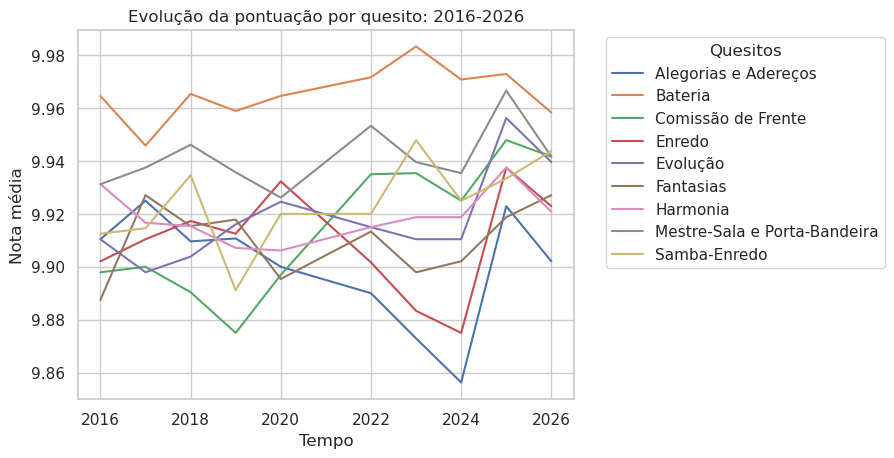

In [34]:
# Gráfico 7: Evolução da pontuação por quesito: 2016-2026

res_ques = ['Alegorias e Adereços', 'Bateria', 'Comissão de Frente', 'Enredo', 'Evolução', 'Fantasias', 'Harmonia', 'Mestre-Sala e Porta-Bandeira', 'Samba-Enredo']
res_filter = res[(res['quesito'].isin(res_ques)) & (res['ano'].between(2016,2026))]

res_ques_grouped = (res_filter.groupby(['ano', 'quesito'])['nota'].mean().reset_index())

sns.lineplot(
    data=res_ques_grouped,
    x='ano',
    y='nota',
    hue='quesito')

plt.title('Evolução da pontuação por quesito: 2016-2026')
plt.ylabel('Nota média')
plt.xlabel('Tempo')
plt.legend(title='Quesitos', bbox_to_anchor=(1.05,1))
plt.show()

**A variação nas médias de cada quesito ocorre entre 9.8 e 10, e no biênio de 2024-2026 esse intervalo diminui para 9.9 e 10**. Na percepção dos jurados, **parece haver então uma gradual aproximação na competitividade entre as escolas**; o estabelecimento de critérios cada vez mais objetivos para o julgamento pode em partes explicar essa tendência, como ensaiado nos gráficos do período total (1996-2026), mas é talvez o efeito dessas mudanças que esses dados capturam, isto é, **quanto mais objetividade nos critérios usados para aplicar notas, mais a própria percepção de quem aplica essas notas se torna também objetiva**. Não por acaso o quesito bateria, o único no qual se sentiu a necessidade, nesse último carnaval, de incluir subquesitos para justificar as frações de nota, mostra a evolução mais estável; há outros quesitos com estabilidade mais sutil que também devem ser mencionados, como harmonia (cuja variação na média de notas entre 2016 e 2016 foi em um intervalo de 0.04 e não apresentou nenhuma mudança brusca na curva) e samba-enredo (que apesar de apresentar algumas subidas e descidas bruscas, variou em um intervalo de cerca de 0.05). Além disso, há também um último aspecto que se torna visível na figura, entre 2022 e 2026: **o caminho mais ou menos conjunto que percorrem alegorias e adereços, enredo, evolução, mestre-sala e porta-bandeira e, não tão próximo, harmonia**. Parece que _a média de notas nesses quesitos andam juntas_: uma curva descendente em alegorias e adereços de 2022 a 2024 foi acompanhada quase com mesma intensidade por enredo, assim como a curva ascendente entre 2024 e 2026, e ambas foram acompanhadas em ritmo pelos outros quesitos citados; a média maior ou menor em uma é acompanhada de médias maiores ou menores nas outras. Esse comportamento é muito diferente da média de notas no primeiro terço do período maior, entre 1996 e 2026, em que parecia não haver nenhum tipo de padrão detectável entre os movimentos das notas nos diferentes quesitos.

### Breves conclusões

Muitos *insights* ainda podem (e devem) ser extraídos desse volume significativo de dados para preencher lacunas importantes, como por exemplo padrões de penalização, ou comparações entre nota em quesitos como enredo vs. tema do enredo apresentado pela escola, etc. Entretanto, algumas conclusões importantes resultaram dessa breve análise que fizemos, e as principais são:

- a regulação da LIESA, na forma das constantes e intenças mudanças nos critérios de julgamento na primeira metade do período analisado, foi capaz de produzir uma mudança bastante significativa na forma como os jurados se comportam: passou-se de uma situação onde as notas eram atribuídas praticamente sem nenhum padrão detectável para um segundo momento, na segunda metade do período, em que a evolução das médias se mostrou muito mais estável e com padrões detectáveis;
- essa mudança no comportamento médio deve, a meu ver e pelo menos em alguma medida, ser entendida como uma caminhada gradual na direção de mais objetividade nos critérios de julgamento;
- entre as escolas analisadas, o que se entende como suas "forças estruturais" históricas, quero dizer, os quesitos de mais destaque entre todos em nota média durante um dado período, também muda de acordo com a evolução desse padrão de comportamento na aplicação de notas, mas algumas constantes permanecem: o Salgueiro, por exemplo, tem mais ou menos as mesmas forças estruturais no período total e na última década, assim como a Portela, a Beija-Flor e a Mangueira, enquanto escolas como Vila Isabel e Mocidade, apesar de apresentarem algumas persistências, mudaram bastante na última década;
- a passagem breve ou longa passagem de uma escola pelo Grupo Especial não é tão engessada na percepção dos jurados na hora de aplicar notas: vemos exemplos como a Unidos de Padre Miguel e o Império Serrano, que estiveram quase nenhum tempo ou menos da metade do tempo total analisado no primeiro grupo, e mesmo assim têm média de notas relevantes o suficiente para aparecer entre as 3 melhores colocadas em média por quesito, em alguns quesitos.

Essa dinâmica entre a tentativa de garantir objetividade e a natureza inerentemente imprevisível dos desfiles permeia todo esse período, mas não parece ser determinista nem para um lado, nem para outro. Mesmo assim, o caminho que a LIESA e o comportamento dos jurados têm mostrado ser a tendência para promover competições mais justas é esse: aparar os ruídos que essa imprevisibilidade pode causar, enquanto se mantém salvaguardados os mistérios, as surpresas e a autenticidade de cada desfile.